# Era Eleven: football across eras

Five spins award three players each. A manager and formation are drawn together. Your fifteen players become eleven starters and four substitutes. This notebook lets you play, inspect the data, change the rules, and test how much the results depend on them.

Run every cell in order using **Run All**, then use the interactive controls. Python runs the game; GitHub renders saved outputs but does not run the buttons. Open this file in JupyterLab or VS Code with the Jupyter extension. Dependencies: `python -m pip install -r requirements.txt`.

The offline pool contains published FIFA 18 and FC 24 ratings plus base ICON and HERO reconstructions of historical players. The 2020s pool is a 2023 game snapshot. It does not represent the latest EA FC edition. Every card carries its source and lineage. The match model is an exploratory game model with uncalibrated coefficients.

In [1]:
from pathlib import Path
import sys, json, hashlib, copy
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

ROOT = Path.cwd()
if not (ROOT / "era_eleven").exists():
    raise RuntimeError("Start Jupyter in the repository folder, beside this notebook.")
sys.path.insert(0, str(ROOT))
from era_eleven.data import load_players, validate_players, import_ea_csv, import_pes_csv
from era_eleven.engine import (Config, DraftGame, ROLE_WEIGHTS, FORMATIONS, MANAGERS,
    assign_lineup, rate_team, swap_player, simulate_match, simulate_series, simulate_season)
from era_eleven.render import wrap, card_html, team_html, result_html
from era_eleven.widgets import NotebookGame

players = load_players()
manifest = json.loads((ROOT / "data/manifest.json").read_text(encoding="utf-8"))
assert hashlib.sha256((ROOT / "data/players.json").read_bytes()).hexdigest() == manifest["sha256"]
print(f"Loaded {len(players)} attributed player cards; bundled-file hash matches its manifest.")
plt.rcParams.update({"figure.facecolor":"#09100e", "axes.facecolor":"#14231a",
    "axes.edgecolor":"#6c856e", "text.color":"#e7eadd", "axes.labelcolor":"#e7eadd",
    "xtick.color":"#b8c8b7", "ytick.color":"#b8c8b7", "grid.color":"#38513d"})

Loaded 625 attributed player cards; bundled-file hash matches its manifest.


## 1. Inspect the player pool

`identity` names a person; `id` names a particular card or edition. A draft can use each person once. The ICON era labels are curated career periods. Their attributes remain the published FC 24 reconstruction, rather than becoming season-specific historical measurements.

Earlier classics join the **Legends** pool because that small subset does not cover a complete football formation on its own. The available male-player subset is the scope of this demo.

In [2]:
pool = pd.DataFrame(players)
coverage = pool.groupby(["era", "lineage"]).agg(cards=("id", "size"),
    min_rating=("overall", "min"), max_rating=("overall", "max")).reset_index()
display(coverage)
display(pool[["name", "positions", "era", "season", "overall", "source", "source_date"]].head(15))
display(pool[["stamina", "vision", "finishing"]].isna().sum().rename("Missing detailed attributes").to_frame())

,era,lineage,cards,min_rating,max_rating
0,1990s,published-icon-reconstruction,46,85,94
1,2000s,published-icon-reconstruction,89,85,94
2,2010s,published-season-snapshot,239,80,94
3,2020s,published-season-snapshot,229,81,91
4,Classics,published-icon-reconstruction,22,86,95


,name,positions,era,season,overall,source,source_date
0,Ronaldo,"[ST, CF]",1990s,FC 24 base Icon,94,kaggle-fut-2024,2024-06-07
1,Paolo Maldini,"[CB, LB]",1990s,FC 24 base Icon,92,kaggle-fut-2024,2024-06-07
2,Franco Baresi,[CB],1990s,FC 24 base Icon,91,kaggle-fut-2024,2024-06-07
3,Marco van Basten,"[ST, CF]",1990s,FC 24 base Icon,91,kaggle-fut-2024,2024-06-07
4,Roberto Baggio,"[CAM, CF]",1990s,FC 24 base Icon,91,kaggle-fut-2024,2024-06-07
5,Dennis Bergkamp,"[CF, CAM, ST]",1990s,FC 24 base Icon,90,kaggle-fut-2024,2024-06-07
6,Lothar Matthäus,"[CM, CB, CDM]",1990s,FC 24 base Icon,90,kaggle-fut-2024,2024-06-07
7,Rivaldo,"[LW, LM, CAM, CF]",1990s,FC 24 base Icon,90,kaggle-fut-2024,2024-06-07
8,Ruud Gullit,"[CF, CM, CAM, ST]",1990s,FC 24 base Icon,90,kaggle-fut-2024,2024-06-07
9,Abedi Pelé,"[CAM, LM, CF]",1990s,FC 24 base Hero,89,kaggle-fut-2024,2024-06-07


,Missing detailed attributes
stamina,157
vision,157
finishing,157


## 2. Tweak the rules, then play

Change these values and rerun the next two cells to rebuild the game. `temperature` controls draft randomness: a smaller value favours high overall ratings, while a larger value spreads the draw. `min_fit` accepts a native position at 1.00 or an adjacent role at 0.88. Chemistry and tactical values are game-design weights.

The squad is selected with a randomized role assignment before the first reveal. Each spin reveals the next three awards. This preserves a complete formation without duplicate people or a hidden final rescue pick.

In [3]:
ERA = "All eras"                 # Legends, 1990s, 2000s, 2010s, 2020s, All eras
DRAFT_SEED = 42
CONFIG = Config(
    temperature=10.0,
    min_fit=0.85,
    chemistry_weight=2.0,
    tactical_weight=2.5,
    base_goals=1.35,
    role_scale=20.0,
    home_advantage=0.12,
    default_stamina=78.0,         # Reported fallback for cards without stamina
    fatigue=0.08,
    auto_subs=True,
)
display(pd.Series(asdict(CONFIG), name="Setting").to_frame())

,Setting
temperature,10.0
min_fit,0.85
chemistry_weight,2.0
tactical_weight,2.5
role_scale,20.0
base_goals,1.35
home_advantage,0.12
default_stamina,78.0
fatigue,0.08
auto_subs,True


In [4]:
lab = NotebookGame(players, config=CONFIG, seed=DRAFT_SEED, era=ERA)
lab.display();

Use **SPIN · 3 players** five times, or **Finish all five spins**. The manager and formation are already drawn. The final panel shows the pitch, substitutes, a match, and repeated trials. In the cells below, `lab.game`, `lab.team`, and `lab.result` are ordinary Python objects that you can inspect.

For a separate browser game using the same Python engine, run `python -m era_eleven.server` in the repository folder and open [localhost:8765](http://127.0.0.1:8765).

## 3. A reproducible draft you can inspect

This programmatic example runs independently of the buttons. The same seed, pool, and configuration reproduce the manager, formation, and five batches. Input row order does not change the result.

In [5]:
draft = DraftGame(players, era=ERA, seed=DRAFT_SEED, config=CONFIG)
batch_rows = []
for spin in range(1, 6):
    awards = draft.spin()
    batch_rows.extend({"Spin": spin, "Player": p["name"], "Rating": p["overall"],
        "Positions": "/".join(p["positions"]), "Era": p["era"], "Source edition": p["season"]} for p in awards)
team = draft.lineup()
assert len(draft.squad) == 15 and len({p["identity"] for p in draft.squad}) == 15
assert len(team["starters"]) == 11 and len(team["bench"]) == 4
display(pd.DataFrame(batch_rows))
display(HTML(wrap(team_html(team))))

,Spin,Player,Rating,Positions,Era,Source edition
0,1,Jay-Jay Okocha,88,CAM/RM/ST,1990s,FC 24 base Hero
1,1,B. Pavard,83,CB/RB,2020s,EA Sports FC 24
2,1,A. Hakimi,84,RB/RWB,2020s,EA Sports FC 24
3,2,Carles Puyol Saforcada,89,CB/RB,2000s,FC 24 base Icon
4,2,Jordi Alba,83,LB,2020s,EA Sports FC 24
5,2,Ederson,83,GK,2010s,FIFA 18
6,3,Patrick Vieira,88,CM,2000s,FC 24 base Icon
7,3,Bruno,84,CM/CDM,2010s,FIFA 18
8,3,M. Brozović,83,CDM/CM,2020s,EA Sports FC 24
9,4,R. Araujo,86,CB/RB,2020s,EA Sports FC 24


## 4. Check role fit and change the eleven

The assignment maximizes the sum of role scores subject to the formation and minimum-fit requirement. The team model then rates attack, control, and defence separately and adds small tactical and pair-complementarity effects. The assignment does not claim to maximize real win probability.

Swapping a substitute keeps the roster at fifteen. An incompatible swap raises a useful error. This example replaces the goalkeeper; change `slot_index` and `incoming` to try another compatible substitution.

In [6]:
assignment = pd.DataFrame([{ "Slot": s["slot"], "Player": s["player"]["name"],
    "Role fit": s["fit"], "Role score": s["role_score"]} for s in team["starters"]])
display(assignment.round(3))
rating = rate_team(team)
display(pd.Series({k:v for k,v in rating.items() if k not in ["links", "stamina_fallbacks"]}, name="Team model").to_frame())
print("Stamina fallback applied to:", ", ".join(rating["stamina_fallbacks"]) or "none")

slot_index = 0
incoming = next(p for p in team["bench"] if "GK" in p["positions"])
changed_team = swap_player(team, slot_index, incoming["id"])
print("Keeper swap:", team["starters"][slot_index]["player"]["name"], "→", incoming["name"])
display(pd.DataFrame([{"Lineup": name, **{k:rate_team(t)[k] for k in ["attack","control","defence","keeper"]}}
    for name,t in [("Original",team),("After swap",changed_team)]]).round(2))

,Slot,Player,Role fit,Role score
0,GK,A. Onana,1.0,83.78
1,LB,Jordi Alba,1.0,78.86
2,CB,R. Araujo,1.0,80.32
3,CB,Carles Puyol Saforcada,1.0,82.59
4,RB,A. Hakimi,1.0,80.97
5,LM,Quaresma,1.0,78.91
6,CM,Patrick Vieira,1.0,82.48
7,CM,M. Brozović,1.0,78.15
8,RM,Jay-Jay Okocha,1.0,83.21
9,ST,L. Martínez,1.0,82.61


,Team model
attack,85.16535
control,83.54035
defence,82.67015
keeper,83.78
role_quality,81.283636
role_fit,1.0
chemistry,0.786751
tactical_fit,0.2232
stamina,80.1
model,uncalibrated attributes + tactical/chemistry p...


Stamina fallback applied to: Carles Puyol Saforcada, Patrick Vieira, Jay-Jay Okocha
Keeper swap: A. Onana → Ederson


,Lineup,attack,control,defence,keeper
0,Original,85.17,83.54,82.67,83.78
1,After swap,85.17,83.54,82.13,81.34


## 5. Play one match and inspect every event

The opponent is another seeded draft from the same era. Goal rates come from a standard log-linear Poisson model. A displayed match samples shot arrivals and shot probabilities, then draws a goal outcome for each shot. Its score is exactly the number of goal events. A game's shot xG is the sum of its sampled shot probabilities; it can differ from the expected goal rate before the game.

At minute 60, the engine can use up to three suitable substitutes if their fresh role score exceeds the fatigued incumbent's score. The second segment uses the changed lineup. Possession is a control-score proxy. None of these displayed match statistics are observed real-match data.

In [7]:
rival_draft = DraftGame(players, era=ERA, seed=DRAFT_SEED + 100000, config=CONFIG)
for _ in range(5): rival_draft.spin()
rival = rival_draft.lineup()
MATCH_SEED = 2026
result = simulate_match(team, rival, seed=MATCH_SEED)
display(HTML(wrap(result_html(result))))
display(pd.DataFrame(result["events"]).head(25).round(3))
assert result["home_goals"] == sum(e["type"] == "Goal" and e["side"] == "home" for e in result["events"])
assert result == simulate_match(team, rival, seed=MATCH_SEED)
print("Goal events reconcile with the score; the same seed replays the same match.")

,minute,side,type,player,xg,out
0,6,away,Shot,Ferenc Puskás,0.057,NaN
1,6,home,Shot,L. Martínez,0.080,NaN
2,15,away,Shot,Vini Jr.,0.057,NaN
3,17,away,Shot,Vini Jr.,0.066,NaN
4,19,home,Shot,Patrick Vieira,0.096,NaN
5,26,home,Shot,Jay-Jay Okocha,0.062,NaN
6,33,home,Shot,Jay-Jay Okocha,0.360,NaN
7,34,home,Shot,Patrick Vieira,0.062,NaN
8,40,home,Shot,Quaresma,0.165,NaN
9,48,home,Shot,Patrick Vieira,0.087,NaN


Goal events reconcile with the score; the same seed replays the same match.


## 6. Repeat matches and test sensitivity

A single score is a noisy draw. Repeated trials show the result distribution under the current settings. These intervals report simulation sampling error only. They exclude uncertainty in game ratings, historical era comparability, tactical weights, and the player-to-goal mapping.

The sensitivity sweep holds the roster and random seed fixed. It changes the player-to-goal scale, which lets you see how much the result depends on that untrained coefficient.

,Outcome,Probability,Sampling lower,Sampling upper
0,wins,0.4942,0.4803,0.5081
1,draws,0.1900,0.1791,0.2009
2,losses,0.3158,0.3029,0.3287


Approximate 95% Monte Carlo sampling intervals; exclude model uncertainty.


,Goal-rate scale,wins,draws,losses,Expected home goals,Expected away goals
0,12.0,0.5422,0.1694,0.2884,3.0734,2.3710
1,16.0,0.5104,0.1918,0.2978,2.5780,2.0550
2,20.0,0.4942,0.1900,0.3158,2.3201,1.8873
3,26.0,0.4686,0.2136,0.3178,2.1050,1.7455
4,32.0,0.4714,0.2144,0.3142,1.9808,1.6628


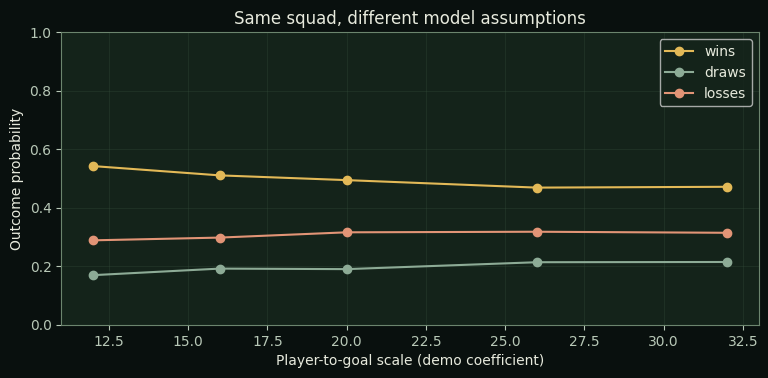

In [8]:
TRIALS = 5000
series = simulate_series(team, rival, n=TRIALS, seed=MATCH_SEED)
probability_table = pd.DataFrame([{"Outcome": key, "Probability": p,
    "Sampling lower": series["sampling_intervals"][key][0],
    "Sampling upper": series["sampling_intervals"][key][1]}
    for key,p in series["probabilities"].items()])
display(probability_table.round(4))
print(series["interval_note"])

sensitivity = []
for scale in [12.0, 16.0, 20.0, 26.0, 32.0]:
    cfg = replace(CONFIG, role_scale=scale)
    trial = simulate_series(team, rival, n=TRIALS, seed=MATCH_SEED, config=cfg)
    sensitivity.append({"Goal-rate scale": scale, **trial["probabilities"],
        "Expected home goals": trial["home_xg"], "Expected away goals": trial["away_xg"]})
sensitivity = pd.DataFrame(sensitivity)
display(sensitivity.round(4))
fig, ax = plt.subplots(figsize=(9,3.8))
for column,color in [("wins","#e3b957"),("draws","#8dab96"),("losses","#e29476")]:
    ax.plot(sensitivity["Goal-rate scale"], sensitivity[column], marker="o", label=column, color=color)
ax.set(xlabel="Player-to-goal scale (demo coefficient)", ylabel="Outcome probability", ylim=(0,1),
    title="Same squad, different model assumptions")
ax.legend(facecolor="#14231a", labelcolor="#e7eadd"); ax.grid(alpha=.3); plt.show()

## 7. Run a 38-match gauntlet

This demo plays generated opponent squads. These are not historical club-season fixtures, and the resulting table is not a reconstructed league season. `best_unbeaten` counts consecutive wins and draws. All draws and opponent seeds are reproducible.

In [9]:
opponents = []
for i in range(38):
    other = DraftGame(players, era=ERA, seed=DRAFT_SEED + 200000 + i, config=CONFIG)
    for _ in range(5): other.spin()
    opponents.append(other.lineup())
season = simulate_season(team, opponents, seed=MATCH_SEED)
display(pd.DataFrame([{k:season[k] for k in ["wins","draws","losses","points","best_unbeaten"]}]))
display(pd.DataFrame(season["matches"]).head(10).round(2))
print(season["label"])

,wins,draws,losses,points,best_unbeaten
0,18,7,13,61,7


,match,opponent,outcome,goals_for,goals_against,xg_for,xg_against
0,1,Pep Guardiola,W,1,0,1.60,2.27
1,2,Vicente del Bosque,L,3,5,1.30,2.69
2,3,Arrigo Sacchi,L,1,4,2.00,3.22
3,4,Lionel Scaloni,L,1,4,1.50,2.23
4,5,Zinedine Zidane,L,2,3,0.92,1.64
5,6,Vicente del Bosque,W,2,1,2.45,0.69
6,7,Jürgen Klopp,W,3,2,1.67,1.27
7,8,Lionel Scaloni,W,2,0,1.90,0.57
8,9,Jürgen Klopp,D,1,1,1.27,1.85
9,10,Carlo Ancelotti,L,0,2,0.67,1.60


Synthetic drafted opponents; not historical club-season fixtures.


## 8. Edit players, role weights, or import another edition

The model does not rewrite source ratings. Make a copy to experiment. Custom role weights use the order `pace, shooting, passing, dribbling, defending, physical` and are normalized to sum to one.

The EA importer accepts a SoFIFA-style career CSV with detailed attributes when supplied. The PES importer accepts a CSV with fields such as `Name`, `Position`, `Overall`, `Speed`, `Finishing`, `Low Pass`, and `Defensive Awareness`. It stores its aggregation map and labels the resulting groups as PES proxies. FC and PES aggregate scales are not assumed statistically equivalent. Each importer rejects missing required ratings rather than silently substituting zeros.

User exports and caches belong in the ignored `data/local/` directory. Supply only data you are entitled to use; those files are never needed for the bundled offline game.

In [10]:
edited_players = copy.deepcopy(players)
selected = next(p for p in edited_players if p["name"] == "Lionel Messi" and p["era"] == "2020s")
original_pace = selected["pace"]
selected["pace"] = min(99, selected["pace"] + 5)
selected["lineage"] = "user-edited-experiment"
validate_players(edited_players)
print(f"Experimental Messi pace: {original_pace} → {selected['pace']}. Original source pool is unchanged.")

custom_weights = copy.deepcopy(ROLE_WEIGHTS)
custom_weights["ST"] = (0.12, 0.55, 0.12, 0.10, 0.01, 0.10)
alternative = draft.lineup(weights=custom_weights)
display(pd.DataFrame([{"Setting": label, "Mean role score": rate_team(t)["role_quality"]}
    for label,t in [("Default weights",team),("Finishing-first striker weights",alternative)]]))

# Example imports, after saving your exports into data/local/:
# ea_players = import_ea_csv(ROOT / "data/local/male_players.csv", era="2020s", edition=24)
# pes_players = import_pes_csv(ROOT / "data/local/pes_players.csv", era="2000s")
# imported_lab = NotebookGame(ea_players, config=CONFIG, seed=42).display()

Experimental Messi pace: 80.0 → 85.0. Original source pool is unchanged.


,Setting,Mean role score
0,Default weights,81.283636
1,Finishing-first striker weights,81.172727


## 9. Optional real-match analytics

This section analyzes **Argentina v France, World Cup final, 18 December 2022**, using [StatsBomb Open Data](https://github.com/statsbomb/open-data). Turn `RUN_REAL_EVENTS` on to fetch the raw file into an ignored local cache. The game itself runs offline.

StatsBomb's [data agreement](https://github.com/statsbomb/open-data/blob/master/LICENSE.pdf) applies to downloaded events and restricts commercial use and redistribution. The public repository includes no raw StatsBomb events. Analysis is attributed to StatsBomb with its logo.

Measured shot xG, non-penalty xG, shot-linked xA, pass completion, pressures, and forward movement are distinct from game simulation statistics. Shootout events are excluded. Scheduled playing minutes include extra time and exclude stoppage. A forward move means a successful pass or carry with at least ten metres of forward x displacement; it is not FBref's progressive-pass definition. A single match cannot establish a reliable per-90 player ranking.

The xT grid implements [Karun Singh's expected-threat fixed point](https://karun.in/blog/expected-threat.html), using empirical goal frequencies and absorbing failed moves. Empty cells remain zero. This one-match field demonstrates the method; it is too sparse to calibrate the game or rank careers.

In [11]:
RUN_REAL_EVENTS = False          # Set True and rerun this cell to fetch/analyze the final
from era_eleven.events import load_statsbomb, event_metrics, fit_expected_threat, LOGO

if RUN_REAL_EVENTS:
    events = load_statsbomb(3869685, cache_dir=ROOT / "data/local")
    measured = event_metrics(events)
    display(HTML(f'<img src="{LOGO}" alt="StatsBomb" style="max-width:190px;background:white;padding:10px"><p>Data: StatsBomb Open Data. Argentina v France, 18 December 2022.</p>'))
    display(measured[["player","team","scheduled_minutes","xg","npxg","xa","xg_per90",
        "pass_completion","forward_moves_10m","pressures"]].round(3).head(15))
    print(measured.attrs)
    xt = fit_expected_threat(events)
    fig, ax = plt.subplots(figsize=(9,5))
    image = ax.imshow(xt["grid"], origin="lower", cmap="YlGn", extent=[0,105,0,68])
    ax.set(xlabel="Attacking direction → (metres)", ylabel="Pitch width (metres)",
        title="Illustrative single-match expected threat · StatsBomb")
    fig.colorbar(image, ax=ax, label="Expected future goals from zone")
    plt.show()
    print({k:v for k,v in xt.items() if k!="grid"})
else:
    print("Optional real-event analysis is off. Set RUN_REAL_EVENTS=True to load it; the offline game is fully available.")

Optional real-event analysis is off. Set RUN_REAL_EVENTS=True to load it; the offline game is fully available.


## 10. Save your experiment

Exports are local and ignored by Git. The JSON records the squad, assignment, model configuration, seeds, and sampled match. Reopen it to compare experiments or report an unexpected result. The final assertion checks the serialized file.

In [12]:
EXPORTS = ROOT / "exports"
EXPORTS.mkdir(exist_ok=True)
export_path = EXPORTS / f"Era Eleven {ERA} seed {DRAFT_SEED}.json"
payload = {"draft_seed":DRAFT_SEED,"era":ERA,"config":asdict(CONFIG),"squad":draft.squad,
    "team":team,"opponent":rival,"match_seed":MATCH_SEED,"match":result,"series":series}
export_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
restored = json.loads(export_path.read_text(encoding="utf-8"))
assert len(restored["squad"]) == 15 and len(restored["team"]["bench"]) == 4
print("Saved and re-read:", export_path.name)

Saved and re-read: Era Eleven All eras seed 42.json


## Sources and limits

- Game reference: [Eraball](https://eraball.com/). Its visible era/draft/lineup/simulation flow informed this football adaptation. Artwork and code are original.
- Ratings: [Stefano Leone's EA Sports FC 24 dataset](https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset) and [Lucas Silva's Ultimate Team database](https://www.kaggle.com/datasets/lucas142129silva/fifa-23-ultimate-team-players-database). Both publishers declare CC0. The latter's title says FIFA 23, but the retrieved payload is `eafc24_players_2024-06-07.csv`. Exact files, dates, and subset choices appear in `data/manifest.json`.
- Assignment: [SciPy linear_sum_assignment](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html), an exact rectangular linear assignment solver.
- Score-model reference: [penaltyblog's Poisson model documentation](https://penaltyblog.readthedocs.io/en/latest/models/overview.html). This demo implements its standard independent-Poisson structure; player-to-goal coefficients are game settings, not fitted estimates. The shot process uses the Poisson marking construction.
- Event analytics: [StatsBomb Open Data](https://github.com/statsbomb/open-data), with its separate data agreement.
- Expected threat: [Karun Singh, Introducing Expected Threat](https://karun.in/blog/expected-threat.html), with failed-move absorption made explicit.

The earlier local Invincible research project describes a fuller adjusted plus-minus and hypergraph model. Those fitted layers are not claimed here. No measured cross-era calibration, trained player chemistry, latest-edition ratings, online leaderboard, or historical club-season schedule is supplied by this demo.